#  ***VeriFact – Fake News Detection System***

***Stage 3: Implementation – Phase 1***

***Student Information***

| Student Name | Student ID |
|---|---|
| Joudi Atef Melebari | 44411765 |
| Laila Mohammad Sabbag | 445001327 |
| Halima Abdullah Mohammed | 444015444 |
| Mashael Hassan Alyazidi | 445003888 |
| Fatimah Khalid Alamoudi | 444015415 |

# ***Part 1: Data Ingestion and Initial Data Preparation***

*   ***Environment Setup for External Dataset Acquisition***

In [ ]:
# kagglehub provides programmatic access to Kaggle datasets inside the Colab environment.
!pip install kagglehub

*   ***Importing Core Data Processing and Dataset Management Libraries***

In [ ]:
# pandas is used to load, inspect, merge, clean, and structure the dataset in tabular form.
import pandas as pd

# os is used to inspect file paths and verify the availability of downloaded dataset files.
import os

# kagglehub is used to retrieve the selected Kaggle dataset directly into the working environment.
import kagglehub

# Regular expressions are imported to remove unwanted patterns such as URLs, punctuation, and special characters.
import re

# String utilities are imported to access punctuation symbols during text cleaning.
import string

# NLTK provides stopword handling and stemming support for NLP preprocessing.
import nltk

# English stopwords are imported to remove common non-informative words.
from nltk.corpus import stopwords

# PorterStemmer is imported to reduce related word forms into a shared stem representation.
from nltk.stem import PorterStemmer

# train_test_split is used to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# LinearSVC is used to build the Support Vector Machine classification model.
from sklearn.svm import LinearSVC

# accuracy_score measures the overall fraction of correctly classified samples.
from sklearn.metrics import accuracy_score

# precision_score measures the proportion of predicted positives that are truly positive.
from sklearn.metrics import precision_score

# recall_score measures the proportion of actual positives that were correctly identified.
from sklearn.metrics import recall_score

# f1_score computes the harmonic mean of precision and recall.
from sklearn.metrics import f1_score

# confusion_matrix summarizes correct and incorrect predictions across all classes.
from sklearn.metrics import confusion_matrix

# classification_report provides a full breakdown of precision, recall, and F1 per class.
from sklearn.metrics import classification_report

# matplotlib is used to render the confusion matrix as a visual heatmap.
import matplotlib.pyplot as plt

# seaborn is used to produce a styled, annotated heatmap for the confusion matrix.
import seaborn as sns

# numpy is used for numerical operations on the confusion matrix array.
import numpy as np

*   ***Automated Retrieval of the Fake and Real News Dataset from Kaggle***

In [ ]:
# The dataset is downloaded directly from Kaggle to ensure consistent access to the approved data source.
dataset_path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

# The downloaded dataset path is displayed to locate the CSV files used in the ingestion stage.
print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


*   ***Dataset File Integrity and Availability Verification***

In [ ]:
# The dataset directory is inspected to confirm that the required CSV files were downloaded successfully.
dataset_files = os.listdir(dataset_path)

# The available files are displayed to verify the presence of Fake.csv and True.csv before data loading.
print("Available dataset files:", dataset_files)

Available dataset files: ['True.csv', 'Fake.csv']


*   ***Constructing Dataset Access Paths for Structured Data Loading***

In [ ]:
# The fake news file path is constructed to load the class representing fabricated news articles.
fake_file_path = os.path.join(dataset_path, "Fake.csv")

# The real news file path is constructed to load the class representing legitimate news articles.
true_file_path = os.path.join(dataset_path, "True.csv")

# The existence of the fake news file is checked before reading to avoid file access errors.
print("Fake.csv exists:", os.path.exists(fake_file_path))

# The existence of the real news file is checked before reading to ensure both classes are available.
print("True.csv exists:", os.path.exists(true_file_path))

# The fake news dataset is loaded into a DataFrame to represent fabricated news samples.
fake_df = pd.read_csv(fake_file_path)

# The real news dataset is loaded into a DataFrame to represent authentic news samples.
true_df = pd.read_csv(true_file_path)

# The fake dataset dimensions are displayed to verify the number of fake samples and available features.
print("Fake dataset shape:", fake_df.shape)

# The real dataset dimensions are displayed to verify the number of real samples and available features.
print("True dataset shape:", true_df.shape)

Fake.csv exists: True
True.csv exists: True
Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


*   ***Structured Ingestion of Fake and Authentic News Records***

In [ ]:
# The fake news dataset is loaded into a DataFrame to represent fabricated news samples.
fake_df = pd.read_csv(fake_file_path)

# The real news dataset is loaded into a DataFrame to represent authentic news samples.
true_df = pd.read_csv(true_file_path)

# The fake dataset dimensions are displayed to verify the number of fake samples and available features.
print("Fake dataset shape:", fake_df.shape)

# The real dataset dimensions are displayed to verify the number of real samples and available features.
print("True dataset shape:", true_df.shape)

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


*   ***Schema Validation of Dataset Attributes and Feature Structure***

In [ ]:
# The fake dataset columns are displayed to verify the structure of the fabricated news file.
print("Fake dataset columns:")
print(fake_df.columns)

# The real dataset columns are displayed to verify structural consistency with the fake news file.
print("\nTrue dataset columns:")
print(true_df.columns)

Fake dataset columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')

True dataset columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')


*   ***Exploratory Inspection of Raw News Samples***

In [ ]:
# The first twenty fake news records to perform a broader exploratory inspection
fake_df.head(20)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"


*   ***Binary Class Annotation for Supervised Learning Preparation***

In [ ]:
# A binary label is assigned to fake news samples, where 0 represents the fake class.
fake_df["label"] = 0

# A binary label is assigned to real news samples, where 1 represents the real class.
true_df["label"] = 1

# The fake label distribution is displayed to confirm that all fake samples received the correct class value.
print("Fake dataset label distribution:")
print(fake_df["label"].value_counts())

# The real label distribution is displayed to confirm that all real samples received the correct class value.
print("\nTrue dataset label distribution:")
print(true_df["label"].value_counts())

Fake dataset label distribution:
label
0    23481
Name: count, dtype: int64

True dataset label distribution:
label
1    21417
Name: count, dtype: int64


*   ***Unified Consolidation of Multi-Class News Sources***

In [ ]:
# The fake and real datasets are merged into one supervised learning dataset.
combined_df = pd.concat([fake_df, true_df], axis=0)

# The merged dataset size is displayed to verify that both classes were combined correctly.
print("Combined dataset shape:", combined_df.shape)

# The class distribution is displayed to confirm that fake and real labels are preserved after merging.
print("\nClass distribution after merging:")
print(combined_df["label"].value_counts())

Combined dataset shape: (44898, 5)

Class distribution after merging:
label
0    23481
1    21417
Name: count, dtype: int64


*   ***Randomized Distribution of News Samples to Reduce Ordering Bias***

In [ ]:
# The merged dataset is shuffled to prevent ordering bias between fake and real samples.
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# The first five rows are displayed after shuffling to verify that class samples are randomly mixed.
combined_df.head(20)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,"On Wednesday, Democrats took a powerful stance...",News,"June 22, 2016",0
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,President Trump s rally in FL on Saturday was ...,Government News,"Feb 19, 2017",0
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",0
8,North Korea shows no sign it is serious about ...,WASHINGTON (Reuters) - The State Department sa...,worldnews,"December 13, 2017",1
9,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,politicsNews,"May 4, 2016",1


*   ***Checking Missing Values***

In [ ]:
# Missing values are counted in each column to identify incomplete records before preprocessing.
missing_values = combined_df.isnull().sum()

# The missing value summary is displayed to assess whether any data cleaning is required.
print("Missing values per column:")
print(missing_values)

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


*   ***Removing Missing Values***

In [ ]:
# Records containing missing values are removed to ensure complete textual inputs before model training.
combined_df = combined_df.dropna()

# Missing values are checked again to confirm that incomplete records were successfully removed.
print("Missing values after removal:")
print(combined_df.isnull().sum())

Missing values after removal:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


*   ***Checking Duplicate Articles***

In [ ]:
# Duplicate articles are counted using both title and text to detect repeated news content.
duplicate_count = combined_df.duplicated(subset=["title", "text"]).sum()

# The number of duplicate articles is displayed to evaluate the risk of data leakage.
print("Number of duplicated articles:", duplicate_count)

Number of duplicated articles: 5793


*   ***Removing Duplicate Articles***

In [ ]:
# Duplicate articles are removed to reduce memorization effects and improve evaluation reliability.
combined_df = combined_df.drop_duplicates(subset=["title", "text"])

# The dataset size after duplicate removal is displayed to document the final number of unique samples.
print("Dataset shape after removing duplicates:", combined_df.shape)

# Duplicate records are checked again to confirm that repeated articles were successfully removed.
print("Duplicated articles after cleaning:", combined_df.duplicated(subset=["title", "text"]).sum())

Dataset shape after removing duplicates: (39105, 5)
Duplicated articles after cleaning: 0


*   ***Extraction of Primary Textual Features for Classification Tasks***

In [ ]:
# The main textual features and the target label are selected for the fake news classification task.
prepared_df = combined_df[["title", "text", "label"]].copy()

# The prepared dataset dimensions are displayed after excluding non-essential metadata columns.
print("Prepared dataset shape:", prepared_df.shape)

# The selected columns are displayed to verify that only modeling-relevant fields remain.
print("Prepared dataset columns:")
print(prepared_df.columns)

Prepared dataset shape: (39105, 3)
Prepared dataset columns:
Index(['title', 'text', 'label'], dtype='object')


*   ***Construction of Unified Linguistic Input Representations***

In [ ]:
# The title and article body are combined to create one complete textual input for each news sample.
prepared_df["combined_text"] = prepared_df["title"].astype(str) + " " + prepared_df["text"].astype(str)

# The combined textual feature is displayed with its label to verify the final input-output structure.
prepared_df[["combined_text", "label"]].head(20)

,combined_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,0
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,0
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,0
8,North Korea shows no sign it is serious about ...,1
9,Trump signals willingness to raise U.S. minimu...,1


*   ***Final Dataset Integrity and Quality Validation Report***

In [ ]:
# The total number of prepared articles is calculated to document the final dataset size.
total_articles = prepared_df.shape[0]

# The total number of available columns is calculated to summarize the final dataset structure.
total_columns = prepared_df.shape[1]

# The number of fake news samples is calculated based on the assigned class label 0.
fake_samples = (prepared_df["label"] == 0).sum()

# The number of real news samples is calculated based on the assigned class label 1.
real_samples = (prepared_df["label"] == 1).sum()

# The total number of remaining missing values is calculated to confirm data completeness.
remaining_missing_values = prepared_df.isnull().sum().sum()

# The total number of remaining duplicate articles is calculated to confirm uniqueness of textual samples.
remaining_duplicates = prepared_df.duplicated(subset=["title", "text"]).sum()

# A final dataset quality summary is displayed to document the output of the data preparation stage.
print("Final Prepared Dataset Summary")
print("--------------------------------")
print("Number of articles:", total_articles)
print("Number of columns:", total_columns)
print("Columns:", list(prepared_df.columns))
print("Fake news samples:", fake_samples)
print("Real news samples:", real_samples)
print("Remaining missing values:", remaining_missing_values)
print("Remaining duplicated articles:", remaining_duplicates)

Final Prepared Dataset Summary
--------------------------------
Number of articles: 39105
Number of columns: 4
Columns: ['title', 'text', 'label', 'combined_text']
Fake news samples: 17908
Real news samples: 21197
Remaining missing values: 0
Remaining duplicated articles: 0


# ***Part 2: Text Cleaning and Linguistic Normalization Pipeline***

***Text Cleaning and Normalization Before Model Training***

*   ***Downloading Required NLTK Linguistic Resources***

In [ ]:
# Stopword lists are downloaded for English text preprocessing.
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

*   ***Initialization of Text Preprocessing Components***

In [ ]:
# English stopwords are loaded into memory for later removal from the text.
stop_words = set(stopwords.words("english"))

# A stemmer object is created to normalize word variations into common stem forms.
stemmer = PorterStemmer()

*   ***Definition of the Text Cleaning and Preprocessing Pipeline***

In [ ]:
def clean_text(text):

    # Text is converted to lowercase to ensure consistent word representation across all articles.
    text = text.lower()

    # URLs are removed because web links do not provide stable linguistic features for classification.
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Punctuation, numbers, and special characters are removed to reduce textual noise.
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Excess whitespace is normalized to maintain a clean and consistent text structure.
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization is performed by splitting the normalized text into individual word units.
    tokens = text.split()

    # English stopwords are removed because they usually add limited discriminative value.
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming is applied using PorterStemmer to reduce words into their base stem form.
    tokens = [stemmer.stem(word) for word in tokens]

    # The processed tokens are joined back into one cleaned textual representation.
    return " ".join(tokens)

*   ***Applying the Cleaning Pipeline to the Combined News Text***

In [ ]:
# The preprocessing function is applied to each combined news article.
prepared_df["cleaned_text"] = prepared_df["combined_text"].apply(clean_text)

*   ***Inspection of Cleaned Text Samples***

In [ ]:
# The cleaned textual feature is displayed to verify preprocessing quality and normalization consistency.
prepared_df[["cleaned_text", "label"]].head(20)

,cleaned_text,label
0,ben stein call th circuit court commit coup dt...,0
1,trump drop steve bannon nation secur council w...,1
2,puerto rico expect us lift jone act ship restr...,1
3,oop trump accident confirm leak isra intellig ...,0
4,donald trump head scotland reopen golf resort ...,1
5,paul ryan respond dem sitin gun control disgus...,0
6,awesom diamond silk rip press dont believ vide...,0
7,stand cheer ukip parti leader slam germani fra...,0
8,north korea show sign seriou talk us offici wa...,1
9,trump signal willing rais us minimum wage vers...,1


*   ***Validation of Dataset Integrity After Text Cleaning***

In [ ]:
# The total number of cleaned articles is displayed to confirm preprocessing completion.
print("Number of cleaned articles:", prepared_df.shape[0])

# Remaining missing values are checked to ensure preprocessing introduced no null entries.
print("Remaining missing values after text cleaning:")
print(prepared_df.isnull().sum())

Number of cleaned articles: 39105
Remaining missing values after text cleaning:
title            0
text             0
label            0
combined_text    0
cleaned_text     0
dtype: int64


# ***Part 3: TF-IDF Feature Extraction and Text Vectorization***

***Importing TF-IDF Feature Extraction Library***

In [ ]:
# TfidfVectorizer is used to convert textual data into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

*   ***Preparation of Cleaned Text Features and Labels***

In [ ]:
# The cleaned textual feature is selected for feature extraction.
X_text = prepared_df["cleaned_text"]

# The target labels are selected for supervised learning.
y = prepared_df["label"]

# The TF-IDF vectorizer is initialized with a maximum vocabulary size of 5000 features.
# Bi-grams are included to improve textual feature representation.
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

*   ***Transformation of Cleaned News Text into Numerical TF-IDF Features***

In [ ]:
# The cleaned text is transformed into numerical TF-IDF feature vectors.
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

# Feature extraction results are displayed for verification.
print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

# Display sample numerical TF-IDF features.
print(X_tfidf[:5])

# ***Part 4: Training and Evaluation of the SVM Classification Model***

*   ***Splitting the Dataset for Model Training***

In [ ]:
# train_test_split is used to divide the dataset into training and testing subsets.
from sklearn.model_selection import train_test_split

# The TF-IDF features are selected as model inputs.
X = X_tfidf

# The target labels are selected for supervised classification.
y = prepared_df["label"]

# The dataset is divided into training and testing subsets using an 80/20 ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# The number of training and testing samples is displayed.
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

*   ***Training the Support Vector Machine Classification Model***

In [ ]:
# The SVM classifier is initialized for fake news classification.
# probability=True enables confidence score generation.
svm_model = SVC(
    kernel="linear",
    C=1,
    probability=True,
    random_state=42
)

# The SVM model is trained using the training data.
svm_model.fit(X_train, y_train)

# A confirmation message is displayed after successful training.
print("SVM model training completed successfully")

*   ***Generating Predictions Using the Trained SVM Model***

In [ ]:
# The trained model predicts labels for the testing dataset.
y_pred = svm_model.predict(X_test)

# The trained model predicts probabilities for confidence score generation.
y_proba = svm_model.predict_proba(X_test)

# The confidence score is extracted from prediction probabilities.
confidence_scores = y_proba.max(axis=1)

# Prediction completion status is displayed.
print("Prediction completed successfully")
print("Number of predictions:", len(y_pred))

*   ***Displaying Sample Predictions Generated by the SVM Model***

In [ ]:
# A sample of predicted labels and confidence scores is displayed to verify model prediction behavior.
sample_predictions = pd.DataFrame({
    "Actual Label": y_test[:20].values,
    "Predicted Label": y_pred[:20],
    "Confidence Score": [round(score * 100, 2) for score in confidence_scores[:20]]
})

sample_predictions

# ***Part 5: Performance Evaluation and Classification Analysis***

*  ***Quantitative Accuracy Assessment of the SVM Classification Model***

In [ ]:
# Accuracy is computed as the ratio of correctly predicted samples to total samples.
accuracy = accuracy_score(y_test, y_pred)

# The accuracy value is displayed as a percentage to interpret model correctness.
print("Model Accuracy: {:.4f} ({:.2f}%)".format(accuracy, accuracy * 100))

Model Accuracy: 0.9946 (99.46%)


*  ***Class-Wise Precision Evaluation and Prediction Reliability Assessment***

In [ ]:
# Precision is computed for each class using macro averaging to treat classes equally.
precision = precision_score(y_test, y_pred, average='macro')

# Per-class precision is also computed to show the breakdown between fake and real news.
precision_per_class = precision_score(y_test, y_pred, average=None)

# The macro-averaged precision is displayed to summarize overall prediction reliability.
print("Macro-Averaged Precision: {:.4f}".format(precision))
print("Precision per class — Fake (0): {:.4f} | Real (1): {:.4f}".format(
    precision_per_class[0], precision_per_class[1]))

Macro-Averaged Precision: 0.9947
Precision per class — Fake (0): 0.9950 | Real (1): 0.9943


*  ***Class-Wise Recall Evaluation and Detection Coverage Analysis***

In [ ]:
# Recall is computed for each class using macro averaging to ensure balanced evaluation.
recall = recall_score(y_test, y_pred, average='macro')

# Per-class recall is also computed to identify sensitivity for each news category.
recall_per_class = recall_score(y_test, y_pred, average=None)

# The macro-averaged recall is displayed to summarize the model's detection coverage.
print("Macro-Averaged Recall: {:.4f}".format(recall))
print("Recall per class — Fake (0): {:.4f} | Real (1): {:.4f}".format(
    recall_per_class[0], recall_per_class[1]))

Macro-Averaged Recall: 0.9945
Recall per class — Fake (0): 0.9933 | Real (1): 0.9958


* ***F1-Score-Based Performance Balance and Classification Effectiveness Analysis***

In [ ]:
# F1-score is computed as the harmonic mean of precision and recall.
f1 = f1_score(y_test, y_pred, average='macro')

# Per-class F1-score is also computed to reveal class-level performance balance.
f1_per_class = f1_score(y_test, y_pred, average=None)

# The macro-averaged F1-score is displayed to provide a balanced performance summary.
print("Macro-Averaged F1-Score: {:.4f}".format(f1))
print("F1-Score per class — Fake (0): {:.4f} | Real (1): {:.4f}".format(
    f1_per_class[0], f1_per_class[1]))

Macro-Averaged F1-Score: 0.9946
F1-Score per class — Fake (0): 0.9941 | Real (1): 0.9950


*  ***Confusion Matrix Visualization and Class-Level Prediction Error Analysis***

Confusion Matrix:
[[3558   24]
 [  18 4221]]

True Negatives  (Fake correctly identified as Fake):  3558
False Positives (Fake incorrectly identified as Real): 24
False Negatives (Real incorrectly identified as Fake): 18
True Positives  (Real correctly identified as Real):  4221



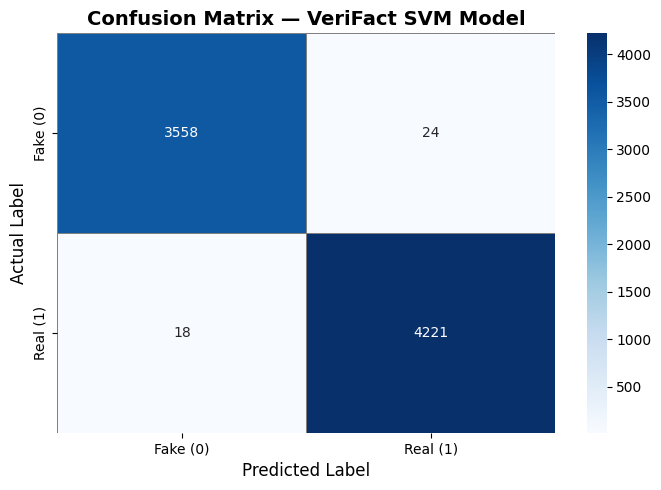

Confusion matrix saved as confusion_matrix.png


In [ ]:
# The confusion matrix is computed to summarize prediction outcomes across all classes.
cm = confusion_matrix(y_test, y_pred)

# The raw confusion matrix values are displayed for reference.
print("Confusion Matrix:")
print(cm)
print()

# Individual cell values are extracted for explicit interpretation.
TN, FP, FN, TP = cm.ravel()
print("True Negatives  (Fake correctly identified as Fake): ", TN)
print("False Positives (Fake incorrectly identified as Real):", FP)
print("False Negatives (Real incorrectly identified as Fake):", FN)
print("True Positives  (Real correctly identified as Real): ", TP)
print()

# A heatmap is created to visualize the confusion matrix with annotation.
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake (0)', 'Real (1)'],
    yticklabels=['Fake (0)', 'Real (1)'],
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Confusion Matrix — VeriFact SVM Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

*  ***Comprehensive Classification Report and Multi-Metric Performance Summary***

In [ ]:
# A detailed classification report is generated to summarize all metrics per class.
report = classification_report(
    y_test,
    y_pred,
    target_names=['Fake News (0)', 'Real News (1)']
)

# The classification report is displayed to document class-level model performance.
print("Classification Report")
print("---------------------")
print(report)

Classification Report
---------------------
               precision    recall  f1-score   support

Fake News (0)       0.99      0.99      0.99      3582
Real News (1)       0.99      1.00      1.00      4239

     accuracy                           0.99      7821
    macro avg       0.99      0.99      0.99      7821
 weighted avg       0.99      0.99      0.99      7821



*  ***Comprehensive Evaluation Summary of the VeriFact Classification Model***

In [ ]:
# All computed evaluation metrics are assembled into a single summary table.
results_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Macro)',
        'Recall (Macro)',
        'F1-Score (Macro)',
        'Precision — Fake (0)',
        'Precision — Real (1)',
        'Recall — Fake (0)',
        'Recall — Real (1)',
        'F1-Score — Fake (0)',
        'F1-Score — Real (1)'
    ],
    'Score': [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(precision_per_class[0], 4),
        round(precision_per_class[1], 4),
        round(recall_per_class[0], 4),
        round(recall_per_class[1], 4),
        round(f1_per_class[0], 4),
        round(f1_per_class[1], 4)
    ]
})

# The results table is displayed to provide a clean, exportable performance overview.
print("VeriFact — SVM Model Evaluation Summary")
print("========================================")
print(results_summary.to_string(index=False))

VeriFact — SVM Model Evaluation Summary
              Metric  Score
            Accuracy 0.9946
   Precision (Macro) 0.9947
      Recall (Macro) 0.9945
    F1-Score (Macro) 0.9946
Precision — Fake (0) 0.9950
Precision — Real (1) 0.9943
   Recall — Fake (0) 0.9933
   Recall — Real (1) 0.9958
 F1-Score — Fake (0) 0.9941
 F1-Score — Real (1) 0.9950
